# Issue #9 — Ensemble Voting Classifier
## Combinación de XGBoost, Random Forest y LightGBM

| Paso | Acción |
|------|--------|
| 1 | Carga de modelos y datos |
| 2 | Cálculo de pesos por F1-macro en CV |
| 3 | Construcción del VotingClassifier (soft voting) |
| 4 | Evaluación en test |
| 5 | Tabla comparativa ensemble vs. modelos individuales |
| 6 | Matriz de confusión final |
| 7 | Guardado del ensemble |

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

PALETTE = {
    'none':   '#ADB5BD',
    'stress': '#4C9BE8',
    'mixed':  '#F4A261',
    'urge':   '#E63946',
}

print('✅ Librerías cargadas.')

✅ Librerías cargadas.


## Paso 1 — Carga de modelos y datos

Cargamos los tres modelos entrenados y los datos de test.
Los modelos ya están ajustados sobre `X_train_scaled` con SMOTE interno;
el test representa la distribución real de producción.

In [48]:
# Datos
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# LabelEncoder de y_train e y_test
le = LabelEncoder()

y_train_encoder = le.fit_transform(y_train)
y_test_encoder  = le.transform(y_test)

print("Clases:", list(le.classes_))

# Configuración de CV compartida
cv_config = joblib.load('../models/cv_config.pkl')
skf = StratifiedKFold(**cv_config)

# Modelos individuales entrenados
rf   = joblib.load('../models/random_forest.pkl')
lgbm = joblib.load('../models/lgbm.pkl')
xgb  = joblib.load('../models/xgboost.pkl')

print('Datos:')
print(f'  X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print()
print('Distribución en test (real):')
print((y_test.value_counts(normalize=True) * 100).round(1))
print()
print('Modelos cargados:')
print(f'  RF:   {rf.__class__.__name__}')
print(f'  LGBM: {lgbm.__class__.__name__}')
print(f'  XGB:  {xgb.__class__.__name__}')

Clases: ['mixed', 'none', 'stress', 'urge']
Datos:
  X_train: (7259, 21) | y_train: (7259,)
  X_test:  (1815, 21)  | y_test:  (1815,)

Distribución en test (real):
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Modelos cargados:
  RF:   RandomForestClassifier
  LGBM: LGBMClassifier
  XGB:  Pipeline


## Paso 2 — Cálculo de pesos por F1-macro en validación cruzada

Calculamos el F1-macro de cada modelo mediante CV 5-fold sobre `X_train`.
Estos scores se usan como pesos del VotingClassifier, de modo que el modelo
más preciso tiene mayor influencia en la decisión final.

> **¿Por qué pesos por CV y no por test?**
> El conjunto de test debe usarse una única vez, al final, para evaluar el
> ensemble ya construido. Usarlo para calcular los pesos sería data leakage.

In [49]:
modelos = {
    'Random Forest': rf,
    'LightGBM':      lgbm,
    'XGBoost':       xgb,
}

print('Calculando F1-macro en CV 5-fold para cada modelo...')
print('=' * 50)

cv_scores = {}
for nombre, modelo in modelos.items():
    scores = cross_val_score ( modelo, X_train, y_train_encoder,
        cv=skf, scoring='f1_macro', n_jobs=-1,
        error_score='raise')
    cv_scores[nombre] = scores.mean()
    print(f'{nombre:<20} F1-macro CV: {scores.mean():.4f} +/- {scores.std():.4f}')

# Los pesos son los F1-macro directamente (valores entre 0 y 1)
# VotingClassifier los normaliza internamente, así que no hace falta escalarlos.
pesos = list(cv_scores.values())

print()
print('Pesos asignados:')
for nombre, peso in zip(cv_scores.keys(), pesos):
    print(f'  {nombre:<20} {peso:.4f}')

Calculando F1-macro en CV 5-fold para cada modelo...
Random Forest        F1-macro CV: 0.4990 +/- 0.0083
LightGBM             F1-macro CV: 0.5027 +/- 0.0111
XGBoost              F1-macro CV: 0.5017 +/- 0.0075

Pesos asignados:
  Random Forest        0.4990
  LightGBM             0.5027
  XGBoost              0.5017


## Paso 3 — Construcción del VotingClassifier

Usamos `voting='soft'` porque los tres modelos soportan `predict_proba()`.
El soft voting promedia las probabilidades de clase ponderadas por el F1-macro
de cada estimador, lo que produce decisiones más calibradas que el hard voting
(que solo cuenta votos de clase mayoritaria).

In [50]:
ensemble = VotingClassifier(
    estimators=[
        ('rf',   rf),
        ('lgbm', lgbm),
        ('xgb',  xgb),
    ],
    voting='soft',
    weights=pesos,   # F1-macro CV de cada modelo
    n_jobs=-1
)

ensemble.fit(X_train, y_train_encoder)

print('✅ Ensemble entrenado.')
print(f'   Estimadores: {[name for name, _ in ensemble.estimators]}')
print(f'   Pesos:       {[round(w, 4) for w in ensemble.weights]}')
print(f'   Voting:      {ensemble.voting}')

✅ Ensemble entrenado.
   Estimadores: ['rf', 'lgbm', 'xgb']
   Pesos:       [np.float64(0.499), np.float64(0.5027), np.float64(0.5017)]
   Voting:      soft


## Paso 4 — Evaluación en test

Evaluamos el ensemble y los modelos individuales en el conjunto de test.
Es la primera vez que estos datos se usan para tomar decisiones.

In [51]:
def evaluar(nombre, modelo, X, y):
    """Devuelve dict con métricas sobre el conjunto dado."""
    y_pred     = modelo.predict(X)
# Normalizar: si las predicciones son strings, encodearlas
    if np.array(y_pred).dtype == object:
        y_pred = le.transform(y_pred)
    
    acc         = accuracy_score(y, y_pred)
    f1_macro    = f1_score(y, y_pred, average='macro')
    f1_weighted = f1_score(y, y_pred, average='weighted')
    return {
        'Modelo':      nombre,
        'Accuracy':    round(acc,          4),
        'F1-macro':    round(f1_macro,     4),
        'F1-weighted': round(f1_weighted,  4),
        'y_pred':      y_pred,
    }

resultados = [
    evaluar('Random Forest', rf,       X_test, y_test_encoder),
    evaluar('LightGBM',      lgbm,     X_test, y_test_encoder),
    evaluar('XGBoost',       xgb,      X_test, y_test_encoder),
    evaluar('Ensemble',      ensemble, X_test, y_test_encoder),
]

# Reporte detallado del ensemble
print('=' * 55)
print('MÉTRICAS FINALES — Ensemble en Test')
print('=' * 55)
y_pred_ensemble = ensemble.predict(X_test)
y_pred_ensemble_labels = le.inverse_transform(y_pred_ensemble)
print(classification_report(y_test, y_pred_ensemble_labels))

# Overfitting check del ensemble
y_pred_train = ensemble.predict(X_train)
f1_train = f1_score(y_train_encoder, y_pred_train, average='macro')
f1_test  = f1_score(y_test_encoder,  y_pred_ensemble, average='macro')
gap = (f1_train - f1_test) * 100
status = '✅ OK < 5%' if gap < 5 else '⚠️  ALTO > 5%'
print(f'Overfitting (F1 train - F1 test): {gap:.2f}%  {status}')

MÉTRICAS FINALES — Ensemble en Test
              precision    recall  f1-score   support

       mixed       0.54      0.52      0.53       328
        none       0.77      0.84      0.81       972
      stress       0.41      0.34      0.37       317
        urge       0.30      0.28      0.29       198

    accuracy                           0.63      1815
   macro avg       0.51      0.50      0.50      1815
weighted avg       0.62      0.63      0.62      1815

Overfitting (F1 train - F1 test): 6.82%  ⚠️  ALTO > 5%


## Paso 5 — Tabla comparativa ensemble vs. modelos individuales

In [52]:
tabla = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in resultados
])

# Marcar el mejor valor en cada métrica
def highlight_best(s):
    is_best = s == s.max()
    return ['font-weight: bold; color: #1a7a4a' if v else '' for v in is_best]

mejor_f1 = tabla['F1-macro'].max()
ensemble_f1 = tabla.loc[tabla['Modelo'] == 'Ensemble', 'F1-macro'].values[0]

print('=' * 60)
print('TABLA COMPARATIVA — Test')
print('=' * 60)
display(
    tabla.set_index('Modelo')
         .style.apply(highlight_best)
         .format('{:.4f}')
)

print()
if ensemble_f1 >= mejor_f1:
    print(f'✅ Definición de hecho cumplida: F1-macro del ensemble ({ensemble_f1:.4f})'
          f' >= mejor modelo individual ({mejor_f1:.4f})')
else:
    diff = mejor_f1 - ensemble_f1
    print(f'⚠️  El ensemble ({ensemble_f1:.4f}) no supera al mejor modelo individual'
          f' ({mejor_f1:.4f}). Diferencia: {diff:.4f}')
    print('   Considera revisar los pesos o el modelo con peor CV.')

TABLA COMPARATIVA — Test


,Accuracy,F1-macro,F1-weighted
Modelo,,,
Random Forest,0.6187,0.4783,0.6061
LightGBM,0.6270,0.4778,0.6089
XGBoost,0.6380,0.4750,0.6120
Ensemble,0.6342,0.5001,0.6241



✅ Definición de hecho cumplida: F1-macro del ensemble (0.5001) >= mejor modelo individual (0.5001)


## Paso 6 — Matriz de confusión final y F1 por clase

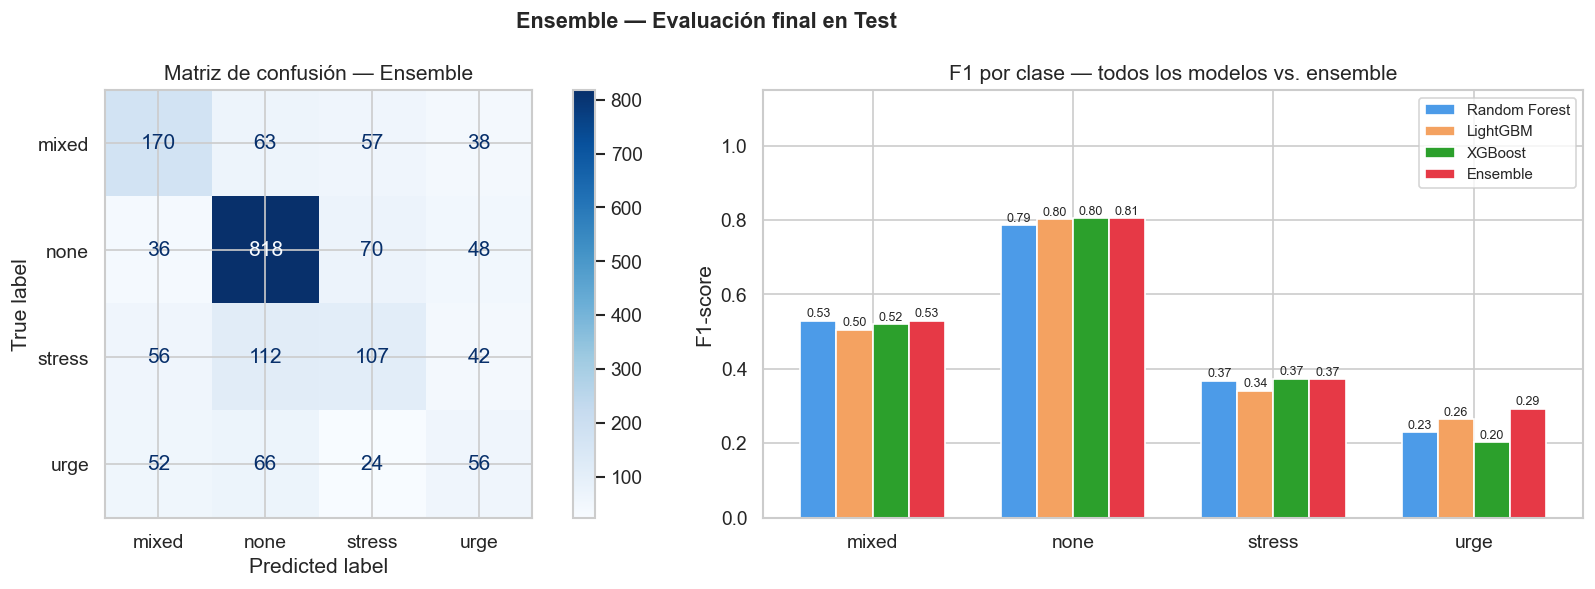

In [53]:
clases_orden = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ensemble — Evaluación final en Test', fontweight='bold', fontsize=13)

# Matriz de confusión
cm = confusion_matrix(y_test_encoder, y_pred_ensemble, labels=np.unique(y_test_encoder))
ConfusionMatrixDisplay(cm, display_labels=clases_orden).plot(
    ax=axes[0], cmap='Blues', colorbar=True
)
axes[0].set_title('Matriz de confusión — Ensemble')

# F1 por clase: ensemble vs. modelos individuales
modelos_plot = {
    'Random Forest': rf,
    'LightGBM':      lgbm,
    'XGBoost':       xgb,
    'Ensemble':      ensemble,
}
colores_modelo = {
    'Random Forest': '#4C9BE8',
    'LightGBM':      '#F4A261',
    'XGBoost':       '#2CA02C',
    'Ensemble':      '#E63946',
}

x      = np.arange(len(clases_orden))
n      = len(modelos_plot)
width  = 0.18

y_test_str = le.inverse_transform(y_test_encoder)  # decode test labels to strings

for idx, (nombre, modelo) in enumerate(modelos_plot.items()):
    y_pred_i = modelo.predict(X_test)
    if hasattr(y_pred_i[0], 'item'): # numpy scalar
        y_pred_i = le.inverse_transform(y_pred_i.astype(int))
    elif y_pred_i.dtype != object:
        y_pred_i = le.inverse_transform(y_pred_i.astype(int))
    
    f1_cls = f1_score(y_test_str, y_pred_i, average=None, labels=clases_orden)
    offset   = (idx - n / 2 + 0.5) * width
    bars = axes[1].bar(
        x + offset, f1_cls, width,
        label=nombre,
        color=colores_modelo[nombre],
        edgecolor='white'
    )
    for bar, val in zip(bars, f1_cls):
        if val > 0.05:
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=7.5
            )

axes[1].set_xticks(x)
axes[1].set_xticklabels(clases_orden)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1 por clase — todos los modelos vs. ensemble')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Paso 7 — Guardado del ensemble

In [54]:
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(ensemble, '../models/ensemble_final.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

print('✅ Label Encoder guardado en models/label_encoder.pkl')
print('✅ Ensemble guardado en models/ensemble_final.pkl')
print()
print('Parámetros del ensemble:')
print(f'  voting:  {ensemble.voting}')
print(f'  weights: {[round(w, 4) for w in ensemble.weights]}')
print(f'  modelos: {[name for name, _ in ensemble.estimators]}')
print()
print('Métricas finales en test:')
print(f'  Accuracy:    {accuracy_score(y_test_encoder, y_pred_ensemble):.4f}')
print(f'  F1-macro:    {f1_score(y_test_encoder, y_pred_ensemble, average="macro"):.4f}')
print(f'  F1-weighted: {f1_score(y_test_encoder, y_pred_ensemble, average="weighted"):.4f}')

✅ Label Encoder guardado en models/label_encoder.pkl
✅ Ensemble guardado en models/ensemble_final.pkl

Parámetros del ensemble:
  voting:  soft
  weights: [np.float64(0.499), np.float64(0.5027), np.float64(0.5017)]
  modelos: ['rf', 'lgbm', 'xgb']

Métricas finales en test:
  Accuracy:    0.6342
  F1-macro:    0.5001
  F1-weighted: 0.6241


## Conclusiones — Ensemble Voting Classifier

### Decisiones de diseño

| Decisión | Justificación |
|----------|---------------|
| `voting='soft'` | Los tres modelos exponen `predict_proba()`. Promediar probabilidades es más informativo que contar votos de clase mayoritaria. |
| Pesos por F1-macro CV | Calculados sobre train con el mismo `StratifiedKFold` compartido, sin tocar el test. Evita data leakage en la selección de pesos. |
| Evaluación final en test | El conjunto de test se usa una única vez, aquí, para reportar rendimiento real. |

### Archivos generados

| Artefacto | Ruta |
|-----------|------|
| `ensemble_final.pkl` | `models/` |

### Próximo paso
Integrar `ensemble_final.pkl` y `pipeline.pkl` en la aplicación web para
realizar predicciones sobre nuevas observaciones.